<a href="https://colab.research.google.com/github/Krishna-matic/python_practice/blob/main/Clustering_Mall_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DataSetForpython/Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.shape

(200, 5)

In [ ]:
df['Genre'].value_counts()

,count
Genre,
Female,112
Male,88


In [ ]:
df['Genre'] = df["Genre"].map({"Female":0,"Male":1})

In [ ]:
x = df.iloc[:,:]
x

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
...,...,...,...,...,...
195,196,0,35,120,79
196,197,0,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


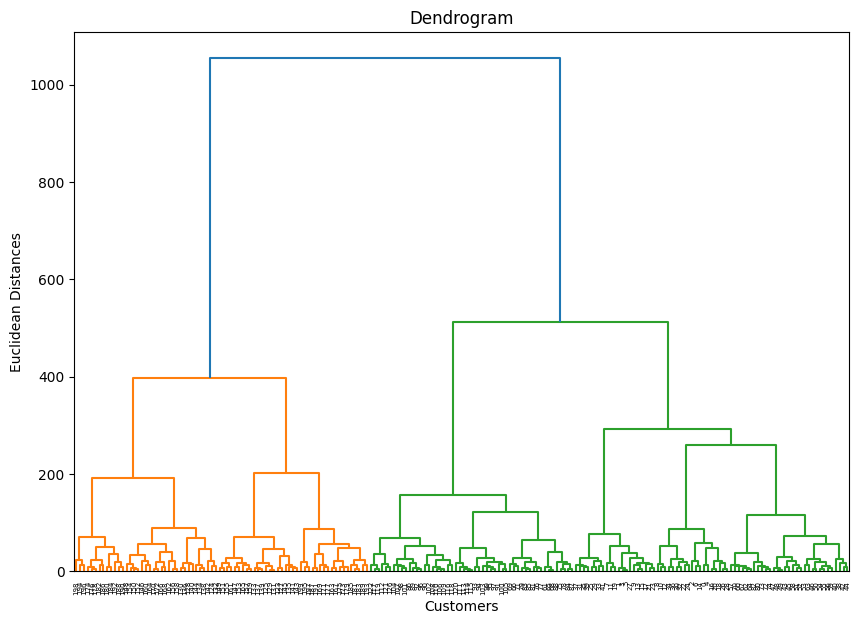

In [ ]:
plt.figure(figsize=(10,7))
dendrogram = sch.dendrogram(sch.linkage(x, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.show()

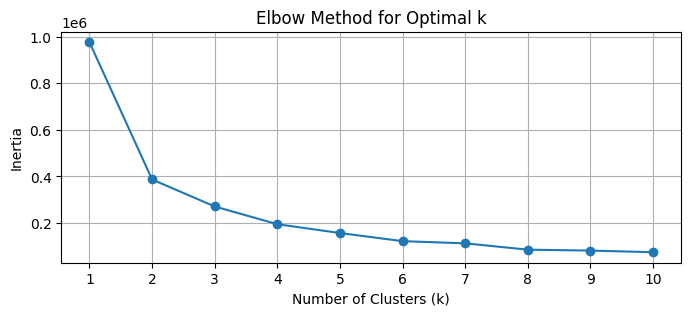

In [ ]:
k_range = range(1, 11)

# List to store the inertia values
inertia_values = []

# Fit KMeans for different values of k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x)
    inertia_values.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(8, 3))
plt.plot(k_range, inertia_values, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x)
    score = silhouette_score(x, labels)
    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.4793
k=3, Silhouette Score=0.3767
k=4, Silhouette Score=0.4225
k=5, Silhouette Score=0.4337
k=6, Silhouette Score=0.4137
k=7, Silhouette Score=0.3602
k=8, Silhouette Score=0.4040
k=9, Silhouette Score=0.3670
k=10, Silhouette Score=0.3464


In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_hc = hc.fit_predict(x)

In [ ]:
y_hc

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2,
       2, 0, 2, 2, 0, 2, 0, 0, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 3, 1, 2, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1])

In [ ]:
df['aglo_y'] = y_hc

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),aglo_y
0,1,1,19,15,39,0
1,2,1,21,15,81,0
2,3,0,20,16,6,0
3,4,0,23,16,77,0
4,5,0,31,17,40,0


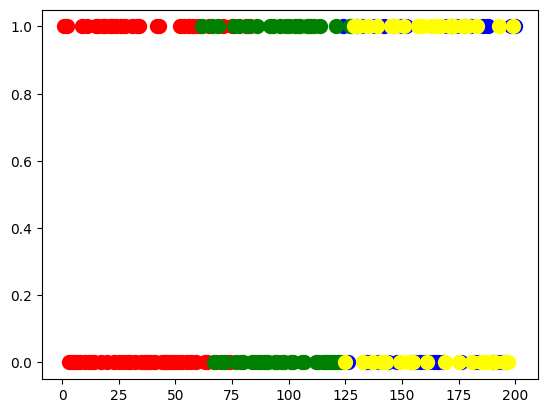

In [ ]:
plt.scatter(x.iloc[y_hc == 0, 0], x.iloc[y_hc == 0, 1], s = 100, c = 'red', label = 'Careful')
plt.scatter(x.iloc[y_hc == 1, 0], x.iloc[y_hc == 1, 1], s = 100, c = 'blue', label = 'Standard')
plt.scatter(x.iloc[y_hc == 2, 0], x.iloc[y_hc == 2, 1], s = 100, c = 'green', label = 'Target')
plt.scatter(x.iloc[y_hc == 3, 0], x.iloc[y_hc == 3, 1], s = 100, c = 'yellow', label = 'Target1')

### **KMeans Clustring**

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(x)

KMeans(n_clusters=4, random_state=42)

Text(0.5, 1.0, 'K-Means Clustering on Dataset')

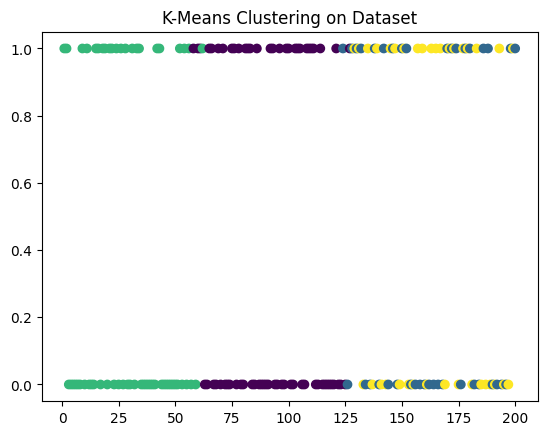

In [ ]:
labels = kmeans.labels_

# Plotting the clusters based on the first two features
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=labels, cmap='viridis')
plt.title('K-Means Clustering on Dataset')

In [ ]:
import plotly.express as px

# Cluster labels
labels = kmeans.labels_

# Create a copy of the data
df = x.copy()
df["Cluster"] = labels.astype(str)  # Convert to string for discrete colors

# 3D Scatter Plot
fig = px.scatter_3d(
    df,
    x=df.columns[0],
    y=df.columns[1],
    z=df.columns[2],
    color="Cluster",
    title="3D K-Means Clustering",
    opacity=0.8,
    width=900,
    height=700
)

fig.update_traces(marker=dict(size=5))

fig.update_layout(
    scene=dict(
        xaxis_title=df.columns[0],
        yaxis_title=df.columns[1],
        zaxis_title=df.columns[2]
    ),
    legend_title="Cluster"
)

fig.show()

In [ ]:
import plotly.graph_objects as go
import plotly.express as px

labels = kmeans.labels_

df = x.copy()
df["Cluster"] = labels.astype(str)

# Scatter plot
fig = px.scatter_3d(
    df,
    x=df.columns[0],
    y=df.columns[1],
    z=df.columns[2],
    color="Cluster",
    opacity=0.8
)

# Add centroids
fig.add_trace(
    go.Scatter3d(
        x=kmeans.cluster_centers_[:, 0],
        y=kmeans.cluster_centers_[:, 1],
        z=kmeans.cluster_centers_[:, 2],
        mode="markers",
        marker=dict(
            size=10,
            color="black",
            symbol="diamond"
        ),
        name="Centroids"
    )
)

fig.update_layout(
    title="3D K-Means Clustering with Centroids",
    scene=dict(
        xaxis_title=df.columns[0],
        yaxis_title=df.columns[1],
        zaxis_title=df.columns[2]
    ),
    width=900,
    height=700
)

fig.show()

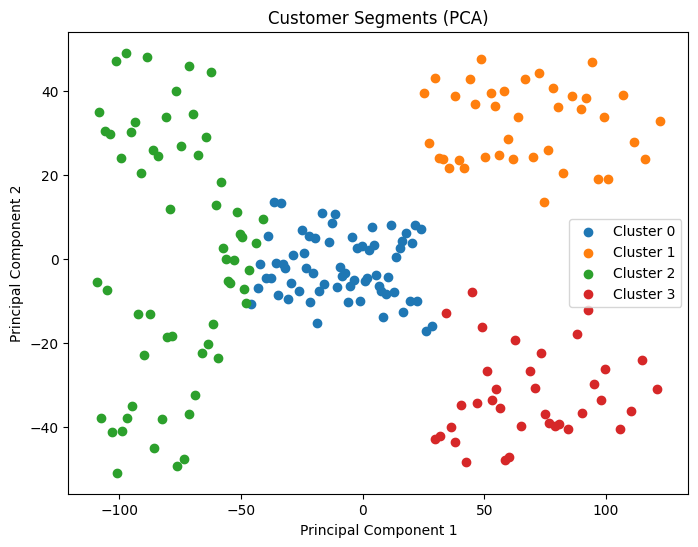

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x)
plt.figure(figsize=(8,6))

for i in range(4):
    plt.scatter(
        X_pca[kmeans.labels_ == i, 0],
        X_pca[kmeans.labels_ == i, 1],
        label=f'Cluster {i}'
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments (PCA)")
plt.legend()
plt.show()